In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# On fixe la seed pour que nos résultats soient reproductibles
np.random.seed(42)
print("Setup terminé ✓")

Setup terminé ✓


In [ ]:
class RandomWalkEnv:
    """
    Environnement de la marche aléatoire à 5 états.
    Positions : 0=FIN gauche, 1=A, 2=B, 3=C, 4=D, 5=E, 6=FIN droite
    """
    
    def __init__(self):
        self.n_states = 7  # 0 à 6
        self.start_position = 3  # on démarre toujours à C
        self.position = self.start_position
    
    def reset(self):
        """Remet l'agent au centre (état C) pour démarrer un nouvel épisode."""
        self.position = self.start_position
        return self.position
    
    def step(self):
        """
        Fait avancer l'agent d'un pas ALÉATOIRE (gauche ou droite, 50/50).
        Retourne : (nouvel état, reward, episode_termine)
        """
        # Tirage aléatoire : -1 (gauche) ou +1 (droite), équiprobable
        move = np.random.choice([-1, 1])
        self.position += move
        
        # Vérifier si on a atteint un état terminal
        if self.position == 6:
            return self.position, 1.0, True  # FIN droite : reward = 1
        elif self.position == 0:
            return self.position, 0.0, True  # FIN gauche : reward = 0
        else:
            return self.position, 0.0, False  # partie continue, reward = 0

In [ ]:
# Test manuel : on simule un épisode et on affiche chaque étape
env = RandomWalkEnv()
state = env.reset()
print(f"Départ : position {state}")

n_steps = 0
done = False

while not done:
    n_steps = n_steps + 1
    state, reward, done = env.step()
    print(f"Nouvelle position : {state}, reward : {reward}, terminé : {done}")

if reward == 1.0 :
    resultat = "Victoire !"
else :
    resultat = "Défaite :("

print(f"Nombre de tours : {n_steps} et le résultat est : {resultat}")
    

Départ : position 3
Nouvelle position : 2, reward : 0.0, terminé : False
Nouvelle position : 3, reward : 0.0, terminé : False
Nouvelle position : 2, reward : 0.0, terminé : False
Nouvelle position : 1, reward : 0.0, terminé : False
Nouvelle position : 0, reward : 0.0, terminé : True
Nombre de tours : 5 et le résultat est : Défaite :(


In [ ]:
# Hyperparamètres
alpha = 0.1
n_episodes = 200

# Initialisation de V
V = np.ones(7) * 0.5
V[0] = 0.0
V[6] = 1.0

# NOUVEAU : une liste pour stocker une COPIE de V à chaque épisode
historique_V = [V.copy()]

env = RandomWalkEnv()
print("V au tout début de cette exécution :", np.round(V, 3))
for episode in range(n_episodes):
    state = env.reset()
    done = False
    
    while not done:
        old_state = state
        state, reward, done = env.step()
        
        if done:
            V[old_state] = V[old_state] + alpha * (reward - V[old_state])
        else:
            V[old_state] = V[old_state] + alpha * (V[state] - V[old_state])
    
    # NOUVEAU : à la fin de CHAQUE épisode, on sauvegarde une photo de V
    historique_V.append(V.copy())
print("Nombre de photos sauvegardées :", len(historique_V))
print(V)

V au tout début de cette exécution : [0.  0.5 0.5 0.5 0.5 0.5 1. ]
Nombre de photos sauvegardées : 201
[0.         0.15772762 0.27463309 0.46050601 0.68454556 0.84674068
 1.        ]


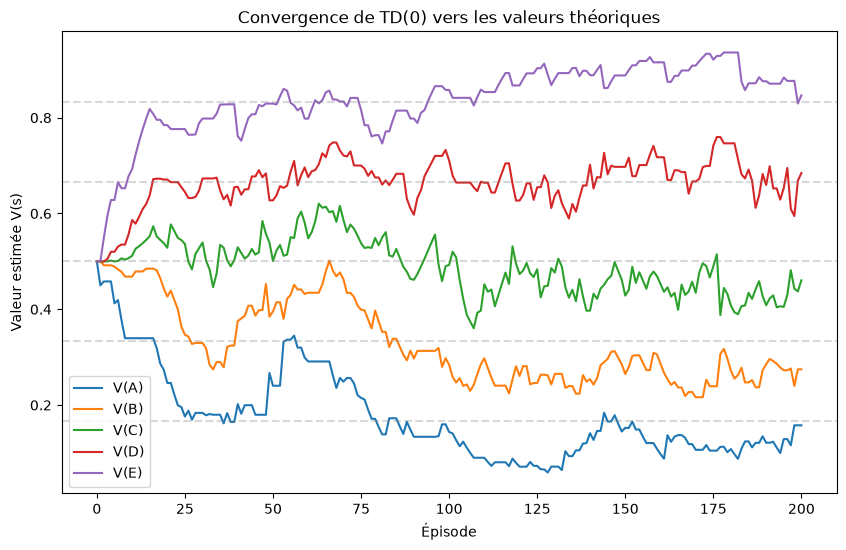

In [ ]:
# On convertit la liste de tableaux en un seul gros tableau 2D
# Chaque ligne = un épisode, chaque colonne = un état
historique_V = np.array(historique_V)

plt.figure(figsize=(10, 6))

# On trace une courbe par état non-terminal (A, B, C, D, E)
labels = ['A', 'B', 'C', 'D', 'E']
for i, label in enumerate(labels):
    indice_etat = i + 1  # A=1, B=2, C=3, D=4, E=5
    plt.plot(historique_V[:, indice_etat], label=f"V({label})")

# Lignes horizontales pour les vraies valeurs théoriques
valeurs_theoriques = [1/6, 2/6, 3/6, 4/6, 5/6]
for v_theo in valeurs_theoriques:
    plt.axhline(y=v_theo, color='gray', linestyle='--', alpha=0.3)

plt.xlabel("Épisode")
plt.ylabel("Valeur estimée V(s)")
plt.title("Convergence de TD(0) vers les valeurs théoriques")
plt.legend()
plt.show()

In [ ]:
def entrainer_td_lambda(n_episodes=200, alpha=0.1, lam=0.8):
    """
    TD(lambda) sur le random walk, avec eligibility traces.
    lam = 0 redonne exactement TD(0).
    Retourne V final et l'historique de V a chaque episode.
    """
    V = np.ones(7) * 0.5
    V[0] = 0.0
    V[6] = 1.0
    
    historique_V = [V.copy()]
    env = RandomWalkEnv()
    
    for episode in range(n_episodes):
        state = env.reset()
        done = False
        
        # Les traces sont remises a zero au debut de CHAQUE episode
        traces = np.zeros(7)
        
        while not done:
            old_state = state
            state, reward, done = env.step()
            
            # 1. Calcul de la TD error (identique a TD(0))
            if done:
                delta = reward - V[old_state]
            else:
                delta = V[state] - V[old_state]
            
            # 2. Mise a jour des traces : decroissance de toutes, +1 sur l'etat visite
            traces = lam * traces
            traces[old_state] += 1
            
            # 3. Mise a jour de V : TOUS les etats a la fois, ponderes par leur trace
            V = V + alpha * delta * traces
            
            # Les etats terminaux restent figes (ils ont une valeur exacte connue)
            V[0] = 0.0
            V[6] = 1.0
        
        historique_V.append(V.copy())
    
    return V, np.array(historique_V)

In [ ]:
def comparer_convergence(n_episodes=100, n_runs=50, alpha=0.1, lam=0.8):
    """
    Compare la vitesse de convergence de TD(0) et TD(lambda),
    moyennee sur n_runs executions independantes pour lisser le bruit.
    Metrique : erreur RMS entre V appris et V theorique, a chaque episode.
    """
    V_theorique = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])
    
    erreurs_td0 = np.zeros(n_episodes + 1)
    erreurs_tdlam = np.zeros(n_episodes + 1)
    
    for run in range(n_runs):
        # TD(0) = TD(lambda) avec lam=0 — on reutilise la MEME fonction
        _, hist_td0 = entrainer_td_lambda(n_episodes, alpha, lam=0.0)
        _, hist_tdlam = entrainer_td_lambda(n_episodes, alpha, lam=lam)
        
        # Erreur RMS a chaque episode, cumulee sur les runs
        erreurs_td0 += np.sqrt(np.mean((hist_td0 - V_theorique)**2, axis=1))
        erreurs_tdlam += np.sqrt(np.mean((hist_tdlam - V_theorique)**2, axis=1))
    
    # Moyenne sur les runs
    erreurs_td0 /= n_runs
    erreurs_tdlam /= n_runs
    
    plt.figure(figsize=(9, 4))
    plt.plot(erreurs_td0, label="TD(0)", color='steelblue')
    plt.plot(erreurs_tdlam, label=f"TD(λ={lam})", color='crimson')
    plt.xlabel("Épisode")
    plt.ylabel("Erreur RMS vs valeurs théoriques")
    plt.title(f"Vitesse de convergence : TD(0) vs TD(λ) — moyenne sur {n_runs} runs")
    plt.legend()
    plt.show()
    
    return erreurs_td0, erreurs_tdlam

erreurs_td0, erreurs_tdlam = comparer_convergence()